# Multiple Linear Regression

Predicting startup `Profit` from `R&D Spend`, `Administration`, `Marketing Spend`, and `State`. Beyond fitting and predicting, this notebook adds the checks a reviewer expects: exploratory correlations, test-set error metrics, statistical significance of each coefficient, a multicollinearity check, and a feature-selection pass via backward elimination.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('50_Startups.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Exploratory data analysis

Before modeling: how do the numeric features relate to each other and to profit? Strongly correlated predictors (a multicollinearity risk for a linear model) or an obviously dominant feature should show up here.

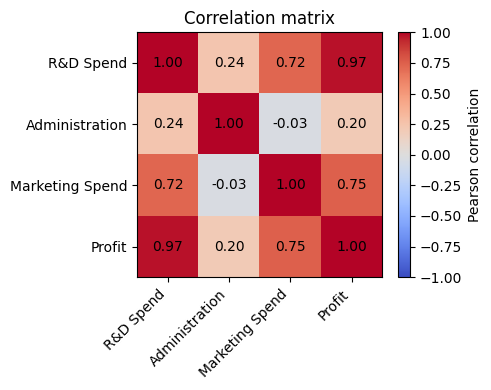

In [3]:
numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
corr = dataset[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation matrix')
fig.tight_layout()
plt.show()

R&D Spend correlates most strongly with Profit, which is a preview of what the coefficient significance check below confirms.

## Encoding categorical data

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

## Splitting the dataset into the Training set and Test set

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Training the Multiple Linear Regression model on the Training set

In [6]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predicting the Test set results

In [7]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]


## Evaluating the model

R², MAE, and RMSE on the held-out test set — the multi-feature analogue of the simple linear regression checks.

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² (test set):   {r2:.4f}')
print(f'MAE (test set):  ${mae:,.2f}')
print(f'RMSE (test set): ${rmse:,.2f}')

R² (test set):   0.9347
MAE (test set):  $7,514.29
RMSE (test set): $9,137.99


### Actual vs. predicted profit (test set)

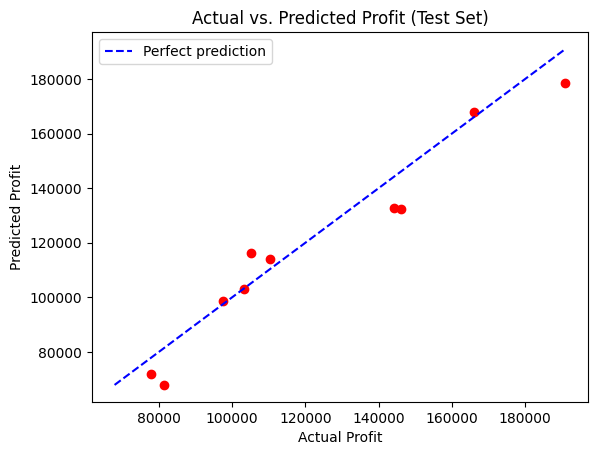

In [9]:
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]

plt.scatter(y_test, y_pred, color='red')
plt.plot(lims, lims, color='blue', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs. Predicted Profit (Test Set)')
plt.legend()
plt.show()

## Predicting a single new example

Note the feature order has to match the training data exactly: the one-hot encoded state columns first (California, Florida, New York, in that order after `OneHotEncoder`), then R&D Spend, Administration, Marketing Spend. This example represents a California startup (`[1, 0, 0]`).

In [10]:
print(regressor.predict([[1, 0, 0, 160000, 130000, 300000]]))

[181566.92]


## Coefficients and intercept

In [11]:
print(regressor.coef_)
print(regressor.intercept_)

[ 8.66e+01 -8.73e+02  7.86e+02  7.73e-01  3.29e-02  3.66e-02]
42467.52924854109


## Statistical significance with statsmodels

Scikit-learn's `LinearRegression` doesn't report p-values or confidence intervals, so it can't tell you whether a coefficient is a real effect or noise. `statsmodels.OLS` does. This refits the same feature set (dropping one dummy column to avoid the dummy variable trap, and adding an explicit intercept) purely to inspect significance — the scikit-learn model above remains the one used for prediction.

In [12]:
import statsmodels.api as sm

# Drop one dummy column (index 0) to avoid the dummy variable trap, then add an intercept term.
X_sm = X[:, 1:].astype(float)
X_sm = sm.add_constant(X_sm)

feature_names = ['const', 'State_Florida', 'State_NewYork', 'R&D Spend', 'Administration', 'Marketing Spend']
ols_model = sm.OLS(y.astype(float), X_sm).fit()
print(ols_model.summary(xname=feature_names))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     169.9
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.34e-27
Time:                        01:07:21   Log-Likelihood:                -525.38
No. Observations:                  50   AIC:                             1063.
Df Residuals:                      44   BIC:                             1074.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5.013e+04   6884.820     

R&D Spend is the only predictor with a p-value comfortably below 0.05 here — consistent with the correlation matrix above. The state dummies and Administration/Marketing Spend do not show statistically significant effects on profit in this sample, which motivates the backward elimination pass below.

## Multicollinearity check (VIF)

Variance Inflation Factor flags predictors that are highly correlated with each other, which inflates coefficient variance and makes individual coefficients unreliable even when the model's overall fit is fine. As a rule of thumb, VIF > 10 signals a problem worth investigating; VIF > 5 is worth a second look.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = feature_names[1:]
vif_data['VIF'] = [variance_inflation_factor(X_sm, i) for i in range(1, X_sm.shape[1])]
vif_data

,feature,VIF
0,State_Florida,1.387641
1,State_NewYork,1.335061
2,R&D Spend,2.495511
3,Administration,1.177766
4,Marketing Spend,2.416797


## Backward elimination

Starting from all features, repeatedly drop the predictor with the highest p-value above a 0.05 significance threshold and refit, until every remaining feature is significant.

In [14]:
def backward_elimination(X, y, feature_names, significance_level=0.05):
    X = X.copy()
    names = list(feature_names)
    while True:
        model = sm.OLS(y, X).fit()
        p_values = model.pvalues
        max_p = p_values.max()
        if max_p <= significance_level or X.shape[1] == 1:
            return model, names
        worst_idx = int(np.argmax(p_values))
        print(f'Dropping {names[worst_idx]!r} (p={max_p:.4f})')
        X = np.delete(X, worst_idx, axis=1)
        del names[worst_idx]

final_model, final_features = backward_elimination(X_sm, y.astype(float), feature_names)
print(f'\nFinal features: {final_features}')
print(final_model.summary(xname=final_features))

Dropping 'State_NewYork' (p=0.9898)
Dropping 'State_Florida' (p=0.9398)
Dropping 'Administration' (p=0.6018)
Dropping 'Marketing Spend' (p=0.0600)

Final features: ['const', 'R&D Spend']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           3.50e-32
Time:                        01:07:21   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef  

Backward elimination lands on **R&D Spend** (plus the intercept) as the only significant predictor of profit in this dataset — Administration, Marketing Spend, and the state dummies all get eliminated. That doesn't mean those features are worthless in general, only that in this particular 50-row sample they don't add statistically detectable signal once R&D Spend is accounted for. This is exactly the kind of finding that's easy to miss from the raw scikit-learn coefficients alone.

## Saving the trained model

Persisted so the Streamlit demo app can load it without retraining. The demo also needs the fitted `ColumnTransformer` to encode new state inputs the same way the training data was encoded.

In [15]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(regressor, '../models/multiple_linear_regression.joblib')
joblib.dump(ct, '../models/multiple_linear_regression_encoder.joblib')
print('Saved model and encoder to ../models/')

Saved model and encoder to ../models/
